## Atividade 1: Carregamento e PCA

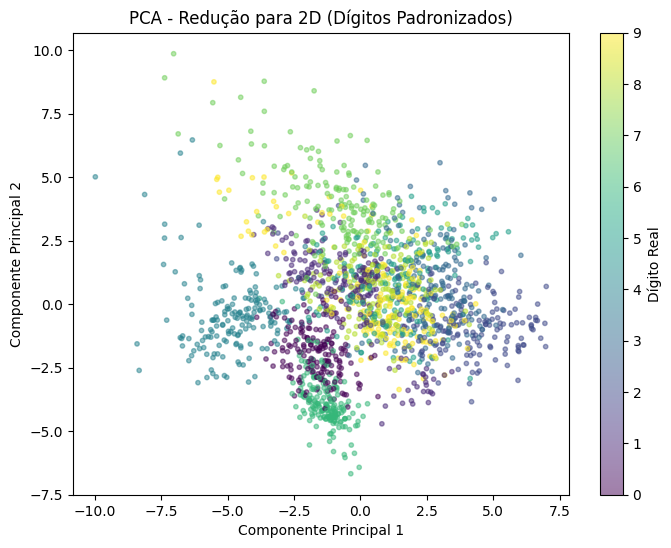

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler  # <-- IMPORTANTE

# 1. Carregar o dataset
digits = load_digits()
data_X = digits.data
data_Y = digits.target

# 1.5 Padronizar os dados (Essencial para o PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_X)

# 2. Redução de dimensão com PCA para 2 componentes (usando os dados padronizados)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualização inicial (nuvem de pontos)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data_Y, cmap='viridis', s=10, alpha=0.5)
plt.colorbar(label='Dígito Real')
plt.title("PCA - Redução para 2D (Dígitos Padronizados)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

## Atividade 2: Divisão dos Dados para Treino e Teste

In [7]:
from sklearn.model_selection import train_test_split

# Dividir os dados em conjuntos de treino e teste
# Usamos X_pca (dados reduzidos) e data_Y (labels reais)
data_X_train, X_test, data_Y_train, y_test = train_test_split(X_pca, data_Y, test_size=0.3, random_state=42)

print(f"Tamanho do conjunto de treino: {data_X_train.shape}")
print(f"Tamanho do conjunto de teste: {X_test.shape}")

Tamanho do conjunto de treino: (1257, 2)
Tamanho do conjunto de teste: (540, 2)


## Atividade 3: Aplicação de K-Means Clustering

In [8]:
from sklearn.cluster import KMeans

# Inicializar e aplicar o K-Means
# Considerando 10 dígitos (0-9), definimos n_clusters=10
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10) # n_init='auto' or int > 1
kmeans.fit(data_X_train)

# Obter os rótulos de cluster para os dados de teste
labels_pred = kmeans.predict(X_test)

# Obter os centroides dos clusters
centroides = kmeans.cluster_centers_

print("K-Means Clustering aplicado com sucesso.")

K-Means Clustering aplicado com sucesso.


## Atividade 4: Avaliação do Modelo K-Means

In [9]:
from sklearn.metrics import adjusted_rand_score, completeness_score, homogeneity_score, v_measure_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np

# Métricas de avaliação de clustering
ars = adjusted_rand_score(y_test, labels_pred)
completeness = completeness_score(y_test, labels_pred)
homogeneity = homogeneity_score(y_test, labels_pred)
v_measure = v_measure_score(y_test, labels_pred)

print(f"Adjusted Rand Index: {ars:.4f}")
print(f"Completude: {completeness:.4f}")
print(f"Homogeneidade: {homogeneity:.4f}")
print(f"V-measure: {v_measure:.4f}")

# Para uma avaliação mais intuitiva (equivalente à 'accuracy' para clustering)
# É necessário mapear os clusters para os rótulos reais

# Criar a matriz de confusão
cm = confusion_matrix(y_test, labels_pred)

# Usar o algoritmo húngaro para encontrar o melhor mapeamento
# entre os rótulos de cluster e os rótulos verdadeiros
row_ind, col_ind = linear_sum_assignment(-cm) # Minimizar negativo para maximizar

# Calcular a 'accuracy' após o mapeamento
mapped_labels_pred = np.zeros_like(labels_pred)
for i in range(len(col_ind)):
    mapped_labels_pred[labels_pred == col_ind[i]] = row_ind[i]

accuracy = np.sum(mapped_labels_pred == y_test) / len(y_test)
print(f"Acurácia (após mapeamento): {accuracy:.4f}")

Adjusted Rand Index: 0.4098
Completude: 0.5559
Homogeneidade: 0.5507
V-measure: 0.5533
Acurácia (após mapeamento): 0.6148


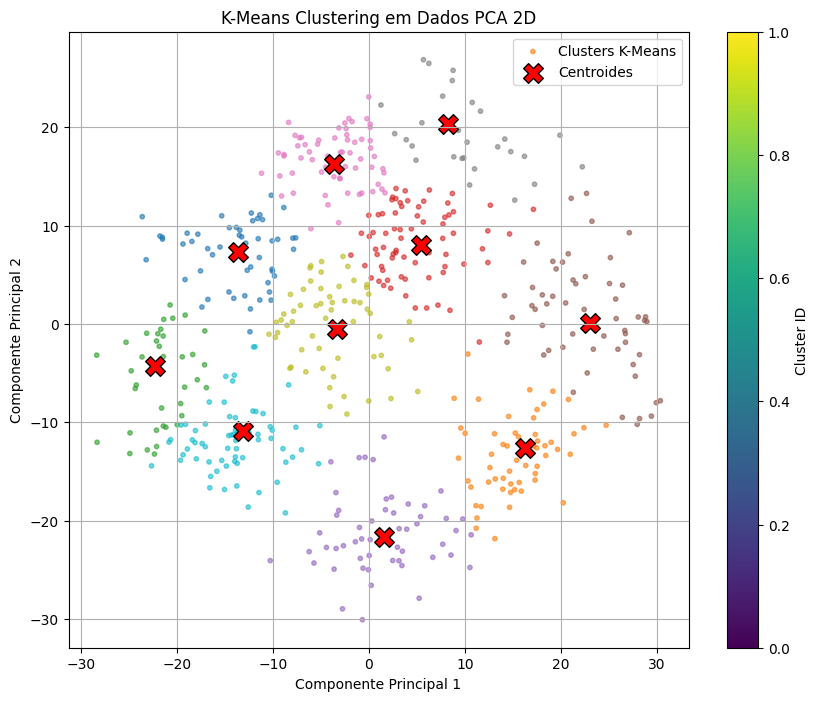

In [10]:
import matplotlib.pyplot as plt

# Visualizar os clusters formados e os centroides
plt.figure(figsize=(10, 8))
plt.scatter(X_test[:, 0], X_test[:, 1], c=labels_pred, cmap='tab10', s=10, alpha=0.6, label='Clusters K-Means')
plt.scatter(centroides[:, 0], centroides[:, 1], marker='X', s=200, c='red', edgecolor='black', label='Centroides')
plt.colorbar(label='Cluster ID')
plt.title("K-Means Clustering em Dados PCA 2D")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True)
plt.show()